<a href="https://colab.research.google.com/github/Em-Esh-Magar/AI-ML_Algorithm/blob/main/Neural_Network/optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Gradient of f(x,y) = x^2 + y^2
def grad(x,y):
  return np.array([2*x, 2*y])

In [ ]:
# Initialize
start = np.array([5.0, 5.0])
steps = 50
lr = 0.1

# Store Trajectories
paths = {}

In [ ]:
# SGD
x = start.copy()
sgd_path = [x.copy()]
for _ in range(steps):
  g = grad(x[0], x[1])
  x = x - lr * g
  sgd_path.append(x.copy())
paths["SGD"] = np.array(sgd_path)

# AdaGrad
x = start.copy()
G = np.zeros(2)
adagrad_path = [x.copy()]
for _ in range(steps):
  g = grad(x[0], x[1])
  G = G + g**2
  x = x - lr * g / (np.sqrt(G) + 1e-8)
  adagrad_path.append(x.copy())
paths["AdaGrad"] = np.array(adagrad_path)

# RMSProp
x = start.copy()
Eg = np.zeros(2)
beta = 0.9
rmsprop_path = [x.copy()]
for _ in range(steps):
  g = grad(x[0], x[1])
  Eg = beta * Eg + (1-beta) * g**2
  x = x - lr *g / (np.sqrt(Eg) + 1e-8)
  rmsprop_path.append(x.copy())
paths["RMSProp"] = np.array(rmsprop_path)


# Adam
x = start.copy()
m = np.zeros(2)
v = np.zeros(2)

beta1, beta2 = 0.9, 0.999

adam_path = [x.copy()]

In [ ]:
for t in range(1, steps+1):
  g = grad(x[0], x[1])

  m = beta1 * m + (1-beta1) * g
  v = beta2 * v + (1-beta2) * (g**2)

  m_hat = m / (1-beta1**t)
  v_hat = v / (1-beta2**t)

  x = x - lr * m_hat / (np.sqrt(v_hat) + 1e-8)

  adam_path.append(x.copy())
paths["Adam"] = np.array(adam_path)

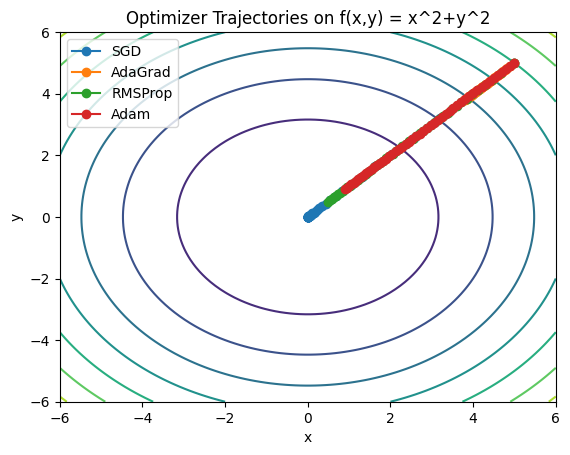

In [ ]:
# plot

plt.figure()

# Contour of loss surface

x_vals = np.linspace(-6, 6, 100)
y_vals = np.linspace(-6, 6, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + Y**2

plt.contour(X, Y, Z)

# plot paths
for name, path in paths.items():
  plt.plot(path[:,0], path[:,1], marker='o', label=name)

plt.legend()
plt.title("Optimizer Trajectories on f(x,y) = x^2+y^2")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

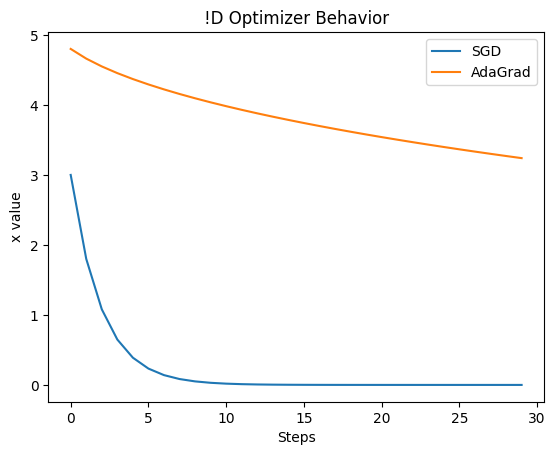

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def grad(x):
  return 2*x

steps = 30
lr = 0.2

# SGD
x = 5
sgd = []
for _ in range(steps):
  x = x - lr * grad(x)
  sgd.append(x)

# AdaGrad
x = 5
G = 0
adagrad = []
for _ in range(steps):
  g = grad(x)
  G += g**2
  x = x - lr * g / (np.sqrt(G) + 1e-8)
  adagrad.append(x)

plt.plot(sgd, label="SGD")
plt.plot(adagrad, label="AdaGrad")
plt.legend()
plt.xlabel("Steps")
plt.ylabel("x value")
plt.title("!D Optimizer Behavior")
plt.show()